# J1.2 v2 — contact-valid exact-truth preflight

Этот отчёт читает batch-артефакт, созданный CLI на commit `84fcbb5`. Он не запускает optimizer и не загружает held-out challenge. Цель — раздельно проверить непрерывную геометрию контакта и её растровое представление, которое будет доступно регистрации.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

candidate = Path.cwd()
REPO_ROOT = candidate if (candidate / "configs").is_dir() else candidate.parent
RESULT_DIR = REPO_ROOT / "results/piecewise_svf_j12_contact_truth_preflight_v2"
MANIFEST_PATH = RESULT_DIR / "manifest.json"
SUMMARY_PATH = RESULT_DIR / "summary.csv"
assert MANIFEST_PATH.is_file() and SUMMARY_PATH.is_file(), "Сначала выполните contact preflight CLI"

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()

manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
summary = pd.read_csv(SUMMARY_PATH)
print(f"artifact: {manifest['artifact_type']}")
print(f"code: {manifest['code_version']}")
print(f"cases: {manifest['truth_pass_count']}/{manifest['case_count']} PASS")
print(
    f"optimizer_started={manifest['optimizer_started']}; "
    f"challenge_loaded={manifest['challenge']['loaded']}"
)

artifact: piecewise_svf_j12_contact_truth_preflight
code: 84fcbb536a1dc2e7389f57c99e8b3263a5599a71
cases: 0/3 PASS
optimizer_started=False; challenge_loaded=False


In [2]:
suite_path = REPO_ROOT / "configs" / manifest["suite_config"]["path"]
search_path = REPO_ROOT / "configs" / manifest["search_config"]["path"]
checks = {
    "suite": sha256(suite_path) == manifest["suite_config"]["sha256"],
    "search": sha256(search_path) == manifest["search_config"]["sha256"],
    "summary": sha256(SUMMARY_PATH) == manifest["summary_sha256"],
}
for name, expected in manifest["diagnostic_sha256"].items():
    checks[name] = sha256(RESULT_DIR / name) == expected
assert all(checks.values()), checks
pd.Series(checks, name="checksum_match").to_frame()

,checksum_match
suite,True
search,True
summary,True
dev_contact_counter_rotation__surface.npz,True
dev_contact_longitudinal_twist__surface.npz,True
dev_contact_shallow_low_texture__surface.npz,True


In [3]:
columns = [
    "case_id",
    "analytic_abs_distance_p95_max_mm",
    "analytic_surface_coverage_min",
    "raster_abs_distance_p95_max_mm",
    "raster_surface_coverage_min",
    "lung_round_trip_p95_mm",
    "body_round_trip_p95_mm",
    "tangential_slip_median_mm",
    "lung_jacobian_p01",
    "body_jacobian_p01",
    "truth_gate_pass",
    "gate_reasons",
]
summary[columns].style.format({
    "analytic_abs_distance_p95_max_mm": "{:.6f}",
    "analytic_surface_coverage_min": "{:.3f}",
    "raster_abs_distance_p95_max_mm": "{:.3f}",
    "raster_surface_coverage_min": "{:.3f}",
    "lung_round_trip_p95_mm": "{:.4f}",
    "body_round_trip_p95_mm": "{:.4f}",
    "tangential_slip_median_mm": "{:.3f}",
    "lung_jacobian_p01": "{:.3f}",
    "body_jacobian_p01": "{:.3f}",
})

,case_id,analytic_abs_distance_p95_max_mm,analytic_surface_coverage_min,raster_abs_distance_p95_max_mm,raster_surface_coverage_min,lung_round_trip_p95_mm,body_round_trip_p95_mm,tangential_slip_median_mm,lung_jacobian_p01,body_jacobian_p01,truth_gate_pass,gate_reasons
0,dev_contact_counter_rotation,0.000643,1.000,0.848,0.922,0.0013,0.0007,3.053,1.156,1.156,False,raster_surface_p95;raster_surface_coverage
1,dev_contact_longitudinal_twist,0.000446,1.000,0.766,0.948,0.0011,0.0017,1.543,1.221,1.221,False,raster_surface_p95;raster_surface_coverage
2,dev_contact_shallow_low_texture,0.000124,1.000,0.753,0.949,0.0003,0.0001,1.339,1.074,1.074,False,raster_surface_p95;raster_surface_coverage


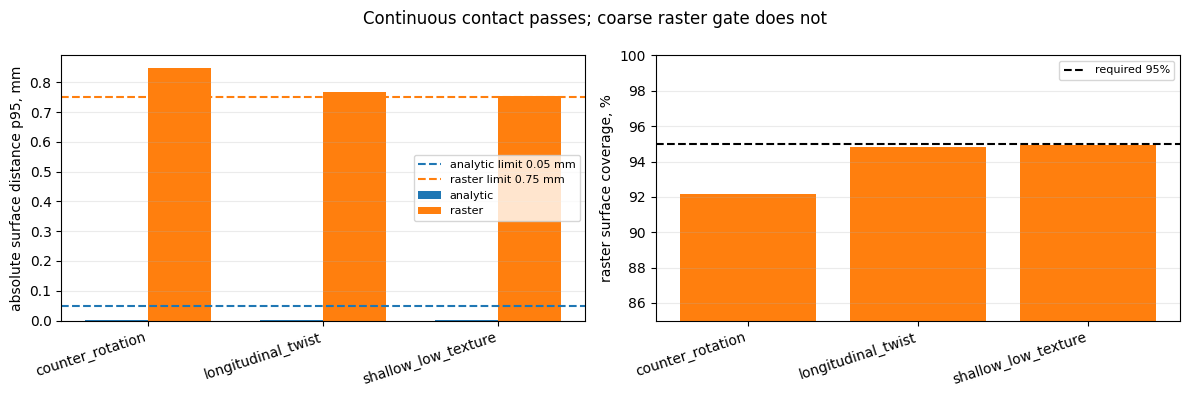

In [4]:
labels = summary["case_id"].str.replace("dev_contact_", "", regex=False)
x = np.arange(len(summary))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(x - 0.18, summary["analytic_abs_distance_p95_max_mm"], 0.36, label="analytic")
axes[0].bar(x + 0.18, summary["raster_abs_distance_p95_max_mm"], 0.36, label="raster")
axes[0].axhline(0.05, color="C0", linestyle="--", label="analytic limit 0.05 mm")
axes[0].axhline(0.75, color="C1", linestyle="--", label="raster limit 0.75 mm")
axes[0].set_ylabel("absolute surface distance p95, mm")
axes[0].set_xticks(x, labels, rotation=18, ha="right")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(x, 100 * summary["raster_surface_coverage_min"], color="C1")
axes[1].axhline(95, color="black", linestyle="--", label="required 95%")
axes[1].set_ylabel("raster surface coverage, %")
axes[1].set_xticks(x, labels, rotation=18, ha="right")
axes[1].set_ylim(85, 100)
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.25)
fig.suptitle("Continuous contact passes; coarse raster gate does not")
fig.tight_layout()
plt.show()

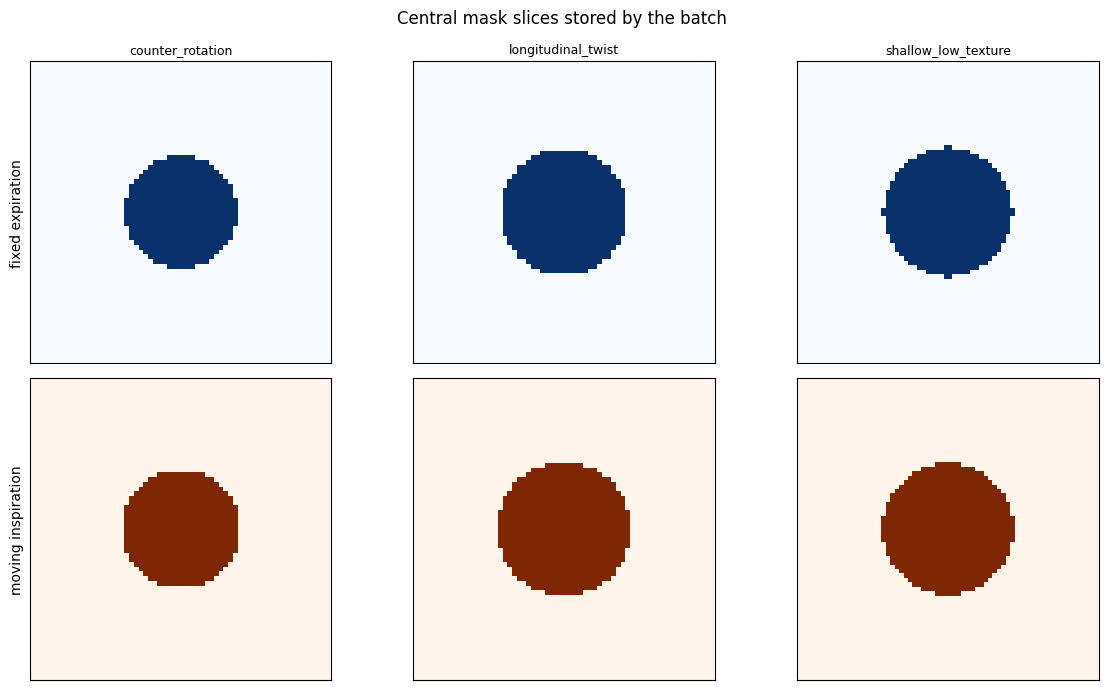

In [5]:
fig, axes = plt.subplots(2, len(summary), figsize=(12, 7))
for column, row in enumerate(summary.itertuples(index=False)):
    artifact = np.load(RESULT_DIR / f"{row.case_id}__surface.npz")
    fixed = artifact["fixed_lung_mask"]
    moving = artifact["moving_lung_mask"]
    z = fixed.shape[2] // 2
    axes[0, column].imshow(fixed[:, :, z].T, origin="lower", cmap="Blues")
    axes[1, column].imshow(moving[:, :, z].T, origin="lower", cmap="Oranges")
    axes[0, column].set_title(row.case_id.replace("dev_contact_", ""), fontsize=9)
    for axis in axes[:, column]:
        axis.set_aspect("equal")
        axis.set_xticks([])
        axis.set_yticks([])
axes[0, 0].set_ylabel("fixed expiration")
axes[1, 0].set_ylabel("moving inspiration")
fig.suptitle("Central mask slices stored by the batch")
fig.tight_layout()
plt.show()

In [6]:
analytic_worst = summary["analytic_abs_distance_p95_max_mm"].max()
raster_worst = summary["raster_abs_distance_p95_max_mm"].max()
coverage_worst = summary["raster_surface_coverage_min"].min()
assert manifest["truth_pass_count"] == 0
assert not manifest["development_search_allowed"]
print("J1.2 v2 DEVELOPMENT BLOCKED")
print(f"continuous contact: PASS, worst p95={analytic_worst:.6f} mm")
print(
    f"raster eligibility: FAIL, worst p95={raster_worst:.3f} mm; "
    f"min coverage={100 * coverage_worst:.1f}%"
)
print("reason: 1.10–1.25 mm binary grids cannot support the frozen 0.75 mm / 95% surface gate")
print(
    "next: freeze a finer-grid protocol with unchanged anatomy, motion and thresholds; "
    "do not start optimizer"
)

J1.2 v2 DEVELOPMENT BLOCKED
continuous contact: PASS, worst p95=0.000643 mm
raster eligibility: FAIL, worst p95=0.848 mm; min coverage=92.2%
reason: 1.10–1.25 mm binary grids cannot support the frozen 0.75 mm / 95% surface gate
next: freeze a finer-grid protocol with unchanged anatomy, motion and thresholds; do not start optimizer
